<a href="https://colab.research.google.com/github/mkane968/digital-text-methods/blob/main/Tutorial_1_Example_Research_Project_Using_Digital_Text_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Tutorial 1: Example Research Project Using Digital Text Methods

Dataset: [MICUSP ENG and BIO Papers](https://docs.google.com/spreadsheets/d/1VjtaY-dacMrcYM9UDcVpF3M4ssGmBrCDG-pse21GXRQ/edit?usp=sharing )

Research Paper: [Tracking Citation Practices Across Di](https://wacclearinghouse.org/docs/jwa/vol8/kane.pdf)

Classroom Application: [Source Mapper](https://sourcemapper.onrender.com/)


### 1. Install Packages

In [ ]:
# Install the packages needed for the tutorial.
!pip -q install openpyxl joblib

# Import packages for working with data.
import io
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import the Google Colab file-upload tool.
from google.colab import files

# Import machine-learning tools.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline

# Import evaluation tools.
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

# Make the graphs look a little nicer.
sns.set_theme(style="whitegrid")

# Use the same random seed every time.
RANDOM_STATE = 42

print("Setup complete.")

Setup complete.


### 2. Upload and Inspect Corpus

In [ ]:
# Open the Google Colab upload box.
uploaded = files.upload()

# Get the name of the uploaded file.
file_name = next(iter(uploaded))

print("Uploaded file:", file_name)

Saving MICUSP Sentences for Machine Learning - Sheet1.csv to MICUSP Sentences for Machine Learning - Sheet1.csv
Uploaded file: MICUSP Sentences for Machine Learning - Sheet1.csv


In [ ]:
# Read the uploaded file based on its extension.
# keep_default_na=False preserves "None" as a real category.

if file_name.lower().endswith(".csv"):
    df = pd.read_csv(
        io.BytesIO(uploaded[file_name]),
        keep_default_na=False
    )

elif file_name.lower().endswith(".tsv"):
    df = pd.read_csv(
        io.BytesIO(uploaded[file_name]),
        sep="\t",
        keep_default_na=False
    )

elif file_name.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(
        io.BytesIO(uploaded[file_name]),
        keep_default_na=False
    )

else:
    raise ValueError(
        "Please upload a CSV, TSV, XLSX, or XLS file."
    )

# Remove accidental spaces from column names.
df.columns = df.columns.astype(str).str.strip()

# Report what was loaded.
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

# Show the rhetorical-function values that were found.
print()
print("Rhetorical Function categories:")
print(df["Rhetorical Function"].value_counts(dropna=False))

# Show the first five rows.
df.head()

Number of rows: 2217
Number of columns: 11

Rhetorical Function categories:
Rhetorical Function
None            1624
Reporting        255
Transforming     253
Evaluating        45
Unclear           35
Questioning        5
Name: count, dtype: int64


,PAPER_ID,TITLE,DISCIPLINE,PAPER TYPE,STUDENT LEVEL,SEX,NATIVENESS,TEXTUAL FEATURES,sentence,Rhetorical Function,sentence_number
0,BIO.G0.15.1,Invading the Territory of Invasives: The Dange...,Biology,Argumentative Essay,Final Year Undergraduate,Male,NNS (L1: Chinese),Reference to sources,"New York City, 1908: different colors of skin...",None,1
1,BIO.G0.15.1,Invading the Territory of Invasives: The Dange...,Biology,Argumentative Essay,Final Year Undergraduate,Male,NNS (L1: Chinese),Reference to sources,Now imagine such a metropolis spreading to cov...,None,2
2,BIO.G0.15.1,Invading the Territory of Invasives: The Dange...,Biology,Argumentative Essay,Final Year Undergraduate,Male,NNS (L1: Chinese),Reference to sources,"Over time, people will weave to produce an unp...",None,3
3,BIO.G0.15.1,Invading the Territory of Invasives: The Dange...,Biology,Argumentative Essay,Final Year Undergraduate,Male,NNS (L1: Chinese),Reference to sources,Our heritages will be remembered only by the h...,None,4
4,BIO.G0.15.1,Invading the Territory of Invasives: The Dange...,Biology,Argumentative Essay,Final Year Undergraduate,Male,NNS (L1: Chinese),Reference to sources,A similar effect can be observed in environmen...,None,5


In [ ]:
# Define the important column names.
TEXT_COLUMN = "sentence"
LABEL_COLUMN = "Rhetorical Function"
PAPER_COLUMN = "PAPER_ID"

# Create a list of the required columns.
required_columns = [
    TEXT_COLUMN,
    LABEL_COLUMN,
    PAPER_COLUMN
]

# Find any required columns that are missing.
missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

# Stop if a required column is missing.
if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}\n"
        f"Available columns: {list(df.columns)}"
    )

print("All required columns were found.")
print()
print("Spreadsheet columns:")
print(list(df.columns))

All required columns were found.

Spreadsheet columns:
['PAPER_ID', 'TITLE', 'DISCIPLINE', 'PAPER TYPE', 'STUDENT LEVEL', 'SEX', 'NATIVENESS', 'TEXTUAL FEATURES', 'sentence', 'Rhetorical Function', 'sentence_number']


### 3. Preprocess Corpus

In [ ]:
# Keep a separate copy for the analysis.
model_df = df.copy()

# Convert the required columns to text and remove extra spaces.
for column in required_columns:
    model_df[column] = (
        model_df[column]
        .astype("string")
        .str.strip()
    )

# Record the original number of rows.
original_rows = len(model_df)

# Remove rows with blank required values.
model_df = model_df[
    (model_df[TEXT_COLUMN].notna()) &
    (model_df[LABEL_COLUMN].notna()) &
    (model_df[PAPER_COLUMN].notna()) &
    (model_df[TEXT_COLUMN] != "") &
    (model_df[LABEL_COLUMN] != "") &
    (model_df[PAPER_COLUMN] != "")
].copy()

# List categories that should not be used for training.
categories_to_remove = [
    "questioning",
    "unclear"
]

# Identify rows belonging to the excluded categories.
excluded_rows = (
    model_df[LABEL_COLUMN]
    .str.lower()
    .isin(categories_to_remove)
)

# Count excluded rows before removing them.
number_excluded = excluded_rows.sum()

# Remove Question and Unclear.
model_df = model_df[
    ~excluded_rows
].copy()

# Count exact duplicate coded sentences.
duplicate_count = model_df.duplicated(
    subset=[
        PAPER_COLUMN,
        TEXT_COLUMN,
        LABEL_COLUMN
    ]
).sum()

# Remove exact duplicate coded sentences.
model_df = model_df.drop_duplicates(
    subset=[
        PAPER_COLUMN,
        TEXT_COLUMN,
        LABEL_COLUMN
    ]
).reset_index(drop=True)

# Report the cleaning results.
print("Original rows:", original_rows)
print("Question/Unclear rows removed:", number_excluded)
print("Exact duplicates removed:", duplicate_count)
print("Final rows:", len(model_df))
print("Number of papers:", model_df[PAPER_COLUMN].nunique())
print("Number of rhetorical categories:", model_df[LABEL_COLUMN].nunique())

print()
print("Remaining rhetorical-function categories:")

display(
    model_df[LABEL_COLUMN]
    .value_counts()
    .rename("Number of Sentences")
    .to_frame()
)

# Make sure at least two categories remain.
if model_df[LABEL_COLUMN].nunique() < 2:
    raise ValueError(
        "The cleaned dataset needs at least two rhetorical-function categories."
    )

Original rows: 2217
Question/Unclear rows removed: 40
Exact duplicates removed: 0
Final rows: 2177
Number of papers: 22
Number of rhetorical categories: 4

Remaining rhetorical-function categories:


,Number of Sentences
Rhetorical Function,
None,1624
Reporting,255
Transforming,253
Evaluating,45


### 4. Preliminary Text Analysis

In [ ]:
# Count the words in each sentence.
model_df["Word Count"] = (
    model_df[TEXT_COLUMN]
    .str.split()
    .str.len()
)

# Identify sentences containing a four-digit year.
model_df["Contains Year"] = (
    model_df[TEXT_COLUMN]
    .str.contains(
        r"\b(?:19|20)\d{2}\b",
        regex=True
    )
)

# Identify sentences containing quotation marks.
model_df["Contains Quotation"] = (
    model_df[TEXT_COLUMN]
    .str.contains(
        r'["“”]',
        regex=True
    )
)

# Identify sentences that end in a question mark.
model_df["Contains Question"] = (
    model_df[TEXT_COLUMN]
    .str.contains(
        r"\?",
        regex=True
    )
)

# Calculate average values for each rhetorical function.
feature_summary = (
    model_df
    .groupby(LABEL_COLUMN)[
        [
            "Word Count",
            "Contains Year",
            "Contains Quotation",
            "Contains Question"
        ]
    ]
    .mean()
    .round(2)
)

display(feature_summary)

,Word Count,Contains Year,Contains Quotation,Contains Question
Rhetorical Function,,,,
Evaluating,26.69,0.38,0.0,0.0
None,22.27,0.01,0.0,0.01
Reporting,26.19,0.69,0.0,0.0
Transforming,30.35,0.69,0.0,0.0


,Number of Sentences
Rhetorical Function,
None,1624
Reporting,255
Transforming,253
Evaluating,45


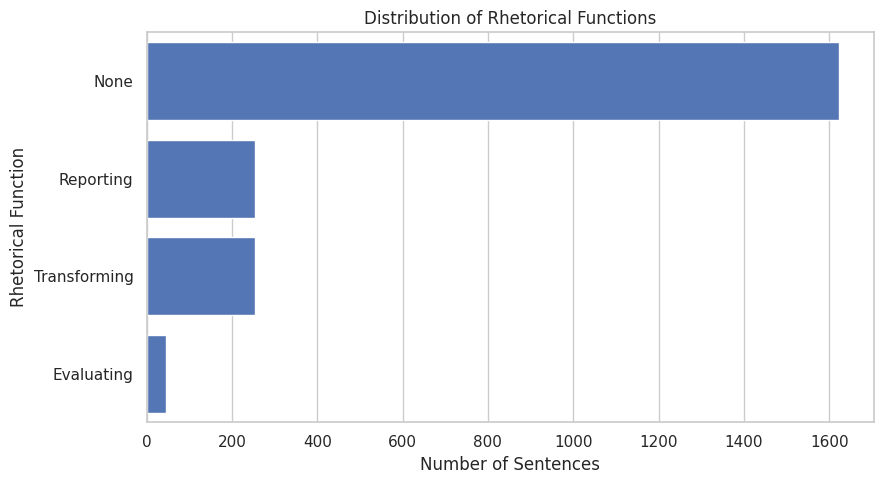

In [ ]:
# Count the number of sentences in each category.
label_counts = model_df[LABEL_COLUMN].value_counts()

# Display the counts as a table.
display(
    label_counts
    .rename("Number of Sentences")
    .to_frame()
)

# Create a bar chart.
plt.figure(figsize=(9, 5))

sns.countplot(
    data=model_df,
    y=LABEL_COLUMN,
    order=label_counts.index,
    color="#4472C4"
)

plt.title("Distribution of Rhetorical Functions")
plt.xlabel("Number of Sentences")
plt.ylabel("Rhetorical Function")
plt.tight_layout()
plt.show()

### 5. Prepare Data for Training

In [ ]:
# X contains the sentences.
X = model_df[TEXT_COLUMN].astype(str)

# y contains the rhetorical-function labels.
y = model_df[LABEL_COLUMN].astype(str)

# groups contains the paper IDs.
groups = model_df[PAPER_COLUMN].astype(str)

print("Number of sentences:", len(X))
print("Number of categories:", y.nunique())
print("Number of papers:", groups.nunique())

Number of sentences: 2177
Number of categories: 4
Number of papers: 22


In [ ]:
# Create a paper-grouped data splitter.
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

# Generate the training and testing row numbers.
train_indices, test_indices = next(
    splitter.split(
        X,
        y,
        groups=groups
    )
)

# Create the training data.
X_train = X.iloc[train_indices]
y_train = y.iloc[train_indices]

# Create the testing data.
X_test = X.iloc[test_indices]
y_test = y.iloc[test_indices]

# Save the paper IDs in each set.
training_papers = set(
    groups.iloc[train_indices]
)

testing_papers = set(
    groups.iloc[test_indices]
)

# Confirm that no paper appears in both sets.
assert training_papers.isdisjoint(testing_papers)

print("Training sentences:", len(X_train))
print("Testing sentences:", len(X_test))
print("Training papers:", len(training_papers))
print("Testing papers:", len(testing_papers))
print()
print("No papers appear in both sets.")

Training sentences: 1615
Testing sentences: 562
Training papers: 17
Testing papers: 5

No papers appear in both sets.


In [ ]:
# Display the category distribution in the training set.
print("TRAINING CATEGORIES")

display(
    y_train
    .value_counts()
    .rename("Training Sentences")
    .to_frame()
)

# Display the category distribution in the testing set.
print("TESTING CATEGORIES")

display(
    y_test
    .value_counts()
    .rename("Testing Sentences")
    .to_frame()
)

# Warn if a test category is missing from training.
missing_from_training = (
    set(y_test.unique()) -
    set(y_train.unique())
)

if missing_from_training:
    print(
        "WARNING: These test categories are absent from training:",
        missing_from_training
    )
    print(
        "You may need more coded papers or a different random seed."
    )
else:
    print("Every testing category also appears in training.")

TRAINING CATEGORIES


,Training Sentences
Rhetorical Function,
None,1196
Transforming,205
Reporting,174
Evaluating,40


TESTING CATEGORIES


,Testing Sentences
Rhetorical Function,
None,428
Reporting,81
Transforming,48
Evaluating,5


Every testing category also appears in training.


### 6. Build and Train Classifier

In [ ]:
# Build the complete classification pipeline.
model = Pipeline([

    # Convert sentence words and two-word phrases
    # into numerical TF-IDF features.
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=1,
            sublinear_tf=True
        )
    ),

    # Train a multiclass logistic-regression classifier.
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )
    )
])

print(model)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])


In [ ]:
# Train the model using the training sentences.
model.fit(
    X_train,
    y_train
)

print("Training complete.")

Training complete.


### 7. Evaluate Classifier Performance

In [ ]:
# Predict the rhetorical function of each test sentence.
predictions = model.predict(X_test)

# Show the first ten predictions.
prediction_preview = pd.DataFrame({
    "Sentence": X_test.reset_index(drop=True),
    "Actual Category": y_test.reset_index(drop=True),
    "Predicted Category": predictions
})

prediction_preview.head(10)

,Sentence,Actual Category,Predicted Category
0,The recurrent cholera pandemics have been rela...,None,None
1,"However, no spatially explicit model has been ...",None,None
2,The first step towards a spatially explicit mo...,None,None
3,"Analysis applying Point Pattern Analysis, Geos...",None,None
4,The world is still suffering the effects of th...,None,None
5,This current pandemic originated in Indonesia...,None,None
6,"Hence, the challenge for epidemiologist nowada...",None,None
7,Because one of the most important goals of epi...,None,None
8,The recurrent epidemics of cholera present pec...,None,None
9,"Only in 1854, John Snow showed that contaminat...",Reporting,Reporting


In [ ]:
# Calculate evaluation measures.
accuracy = accuracy_score(
    y_test,
    predictions
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    predictions
)

macro_f1 = f1_score(
    y_test,
    predictions,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    predictions,
    average="weighted",
    zero_division=0
)

# Put the results in a table.
performance = pd.DataFrame({
    "Measure": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro F1",
        "Weighted F1"
    ],
    "Score": [
        accuracy,
        balanced_accuracy,
        macro_f1,
        weighted_f1
    ]
})

performance["Score"] = performance["Score"].round(3)

display(performance)

,Measure,Score
0,Accuracy,0.801
1,Balanced Accuracy,0.368
2,Macro F1,0.357
3,Weighted F1,0.746


In [ ]:
# Print precision, recall, and F1 for every category.
print(
    classification_report(
        y_test,
        predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

  Evaluating       0.00      0.00      0.00         5
        None       0.84      0.99      0.91       428
   Reporting       0.62      0.06      0.11        81
Transforming       0.39      0.42      0.40        48

    accuracy                           0.80       562
   macro avg       0.47      0.37      0.36       562
weighted avg       0.77      0.80      0.75       562



### 8. Explore Predictive Features

In [ ]:
# Get the trained TF-IDF vectorizer.
tfidf = model.named_steps["tfidf"]

# Get the trained logistic-regression classifier.
classifier = model.named_steps["classifier"]

# Get the words and phrases used by the model.
feature_names = tfidf.get_feature_names_out()

# Create an empty list for the results.
predictive_features = []

# Examine each rhetorical-function category.
for category_number, category_name in enumerate(classifier.classes_):

    # Get the coefficients associated with this category.
    coefficients = classifier.coef_[category_number]

    # Find the 15 features with the largest positive coefficients.
    top_indices = np.argsort(coefficients)[-15:][::-1]

    # Save each predictive feature.
    for rank, feature_index in enumerate(top_indices, start=1):

        predictive_features.append({
            "Rhetorical Function": category_name,
            "Rank": rank,
            "Predictive Word or Phrase": feature_names[feature_index],
            "Model Coefficient": coefficients[feature_index]
        })

# Convert the results into a dataframe.
predictive_features_df = pd.DataFrame(predictive_features)

# Round the coefficient values.
predictive_features_df["Model Coefficient"] = (
    predictive_features_df["Model Coefficient"]
    .round(3)
)

# Display the complete table.
display(predictive_features_df)

,Rhetorical Function,Rank,Predictive Word or Phrase,Model Coefficient
0,Evaluating,1,the paper,1.357
1,Evaluating,2,interesting,1.290
2,Evaluating,3,it,1.213
3,Evaluating,4,not,1.190
4,Evaluating,5,paper,1.113
5,Evaluating,6,striking,1.085
6,Evaluating,7,example illustrates,1.072
7,Evaluating,8,illustrates,1.072
8,Evaluating,9,studies,1.033
9,Evaluating,10,some,0.975


In [ ]:
# Create a table with one rhetorical category per column.
predictive_feature_table = predictive_features_df.pivot(
    index="Rank",
    columns="Rhetorical Function",
    values="Predictive Word or Phrase"
)

display(predictive_feature_table)

Rhetorical Function,Evaluating,None,Reporting,Transforming
Rank,,,,
1,the paper,genes,they,al
2,interesting,the,found that,et al
3,it,color,born,et
4,not,were,2003,2005
5,paper,cross,et,2001
6,striking,we,et al,and
7,example illustrates,crosses,first,by
8,illustrates,marker,al,evidence
9,studies,was,that,and benton


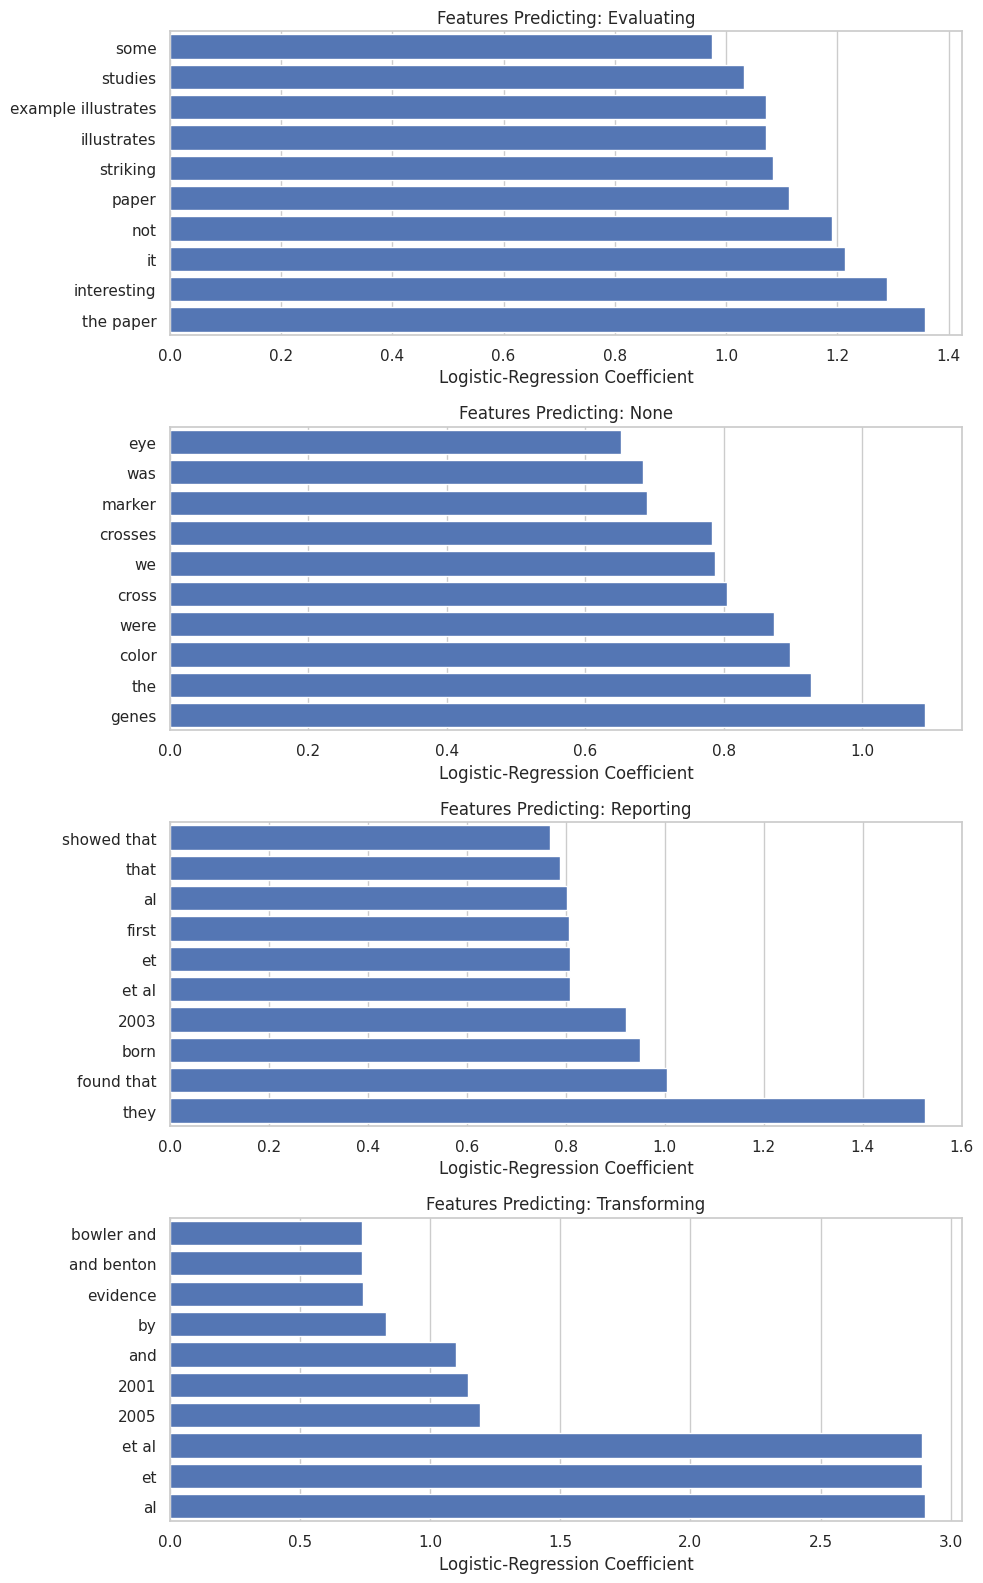

In [ ]:
# Choose how many features to graph for each category.
NUMBER_OF_FEATURES = 10

# Get the strongest features for each category.
features_to_plot = (
    predictive_features_df
    .query("Rank <= @NUMBER_OF_FEATURES")
    .copy()
)

# Get the number of rhetorical categories.
number_of_categories = (
    features_to_plot["Rhetorical Function"]
    .nunique()
)

# Create one graph for each category.
fig, axes = plt.subplots(
    number_of_categories,
    1,
    figsize=(10, 4 * number_of_categories)
)

# Make sure axes is always a list.
if number_of_categories == 1:
    axes = [axes]

# Create each category graph.
for ax, category_name in zip(
    axes,
    classifier.classes_
):

    category_features = features_to_plot[
        features_to_plot["Rhetorical Function"] ==
        category_name
    ].sort_values(
        "Model Coefficient"
    )

    sns.barplot(
        data=category_features,
        x="Model Coefficient",
        y="Predictive Word or Phrase",
        color="#4472C4",
        ax=ax
    )

    ax.set_title(
        f"Features Predicting: {category_name}"
    )

    ax.set_xlabel("Logistic-Regression Coefficient")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()